# Project 2 — Exploratory Data Analysis (EDA)
**DecodeLabs Industrial Training Kit — Batch 2026**

**Role:** Data Analyst Intern
**Mission:** *"The Forensic Architecture of Exploratory Data Analysis."* Take the verified, gold-standard dataset from Project 1 and interrogate it — uncover hidden patterns, trends, and outliers, and translate raw numbers into business insight, before any dashboard or predictive model gets built.

---

## Project Brief Summary

| Item | Detail |
|---|---|
| Goal | Analyze a dataset to understand patterns, trends, and distributions |
| Key requirements | Calculate basic statistics (mean, median, count) - Identify trends and outliers - Summarize key observations |
| Key skills | Data analysis, descriptive statistics, analytical thinking |
| Core framework | **IPO**: Input (the evidence) -> Process (the investigation) -> Output (the verdict) |
| Golden rule | Correlation is a **clue**, not a **verdict** -- always check for hidden/confounding variables |
| Required artifact | An **Executive Summary** following the 4-part architecture: Problem Statement -> Methodology -> Key Findings -> Recommendations |

This notebook works through the forensic framework from the brief:

1. **Phase 0 -- Load the Evidence** (bring in Project 1's cleaned dataset)
2. **Phase 1 -- The Geometry of Distribution** (univariate analysis: shape, mean vs. median)
3. **Phase 2 -- The Logic Skeleton** (five-number summary for every numeric variable)
4. **Phase 3 -- Unmasking the Outliers** (IQR & Z-score methods -- noise vs. signal)
5. **Phase 4 -- Mapping Relationships** (correlation analysis, with the Correlation != Causation warning)
6. **Phase 5 -- Trends Over Time**
7. **The "So What?" Test** -- translate findings into business diagnosis
8. **Executive Summary** -- the final verdict, documented for stakeholders


## 0.1 Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

RAW_PATH = '../data/raw/cleaned_dataset.csv'
PROCESSED_DIR = '../data/processed'
DOCS_DIR = '../docs'
VISUALS_DIR = '../visuals'

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)
os.makedirs(VISUALS_DIR, exist_ok=True)

findings = []  # running list of key findings for the executive summary

def log_finding(finding):
    findings.append(finding)
    print(f"FINDING: {finding}")


## Phase 0 -- Load the Evidence

**Input file:** `cleaned_dataset.csv` -- the verified, gold-standard output of **Project 1: Data Cleaning & Preparation** (0% duplicate IDs, 0% incorrectly formatted dates, all missing values resolved). EDA always starts from trustworthy data; this is the IPO framework's "Input."


In [2]:
df = pd.read_csv(RAW_PATH)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
df.dtypes

Shape: 1200 rows x 14 columns



OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [3]:
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,Save10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,Save10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,Freeship,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,Save10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,Save10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,Save10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,Save10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,Freeship,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,No Coupon,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,Save10,Google,2037.52


In [4]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print(f"\nDate range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Unique customers: {df['CustomerID'].nunique()}  |  Total orders: {len(df)}")


Numeric columns: ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
Categorical columns: ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

Date range: 2023-01-01 to 2025-06-30
Unique customers: 1189  |  Total orders: 1200


## Phase 1 -- The Geometry of Distribution
*"Univariate analysis is the study of one variable's center of gravity."*

For every numeric column, we ask: is the distribution **symmetrical** or **skewed**? That single question decides whether the mean or the median is the trustworthy "center of gravity" for the data.


In [5]:
skew_summary = df[numeric_cols].skew().to_frame('skewness').round(3)
skew_summary['shape'] = skew_summary['skewness'].apply(
    lambda s: 'Symmetrical' if abs(s) < 0.5 else ('Right-skewed' if s >= 0.5 else 'Left-skewed')
)
skew_summary

,skewness,shape
Quantity,0.028,Symmetrical
UnitPrice,-0.027,Symmetrical
ItemsInCart,0.001,Symmetrical
TotalPrice,0.891,Right-skewed


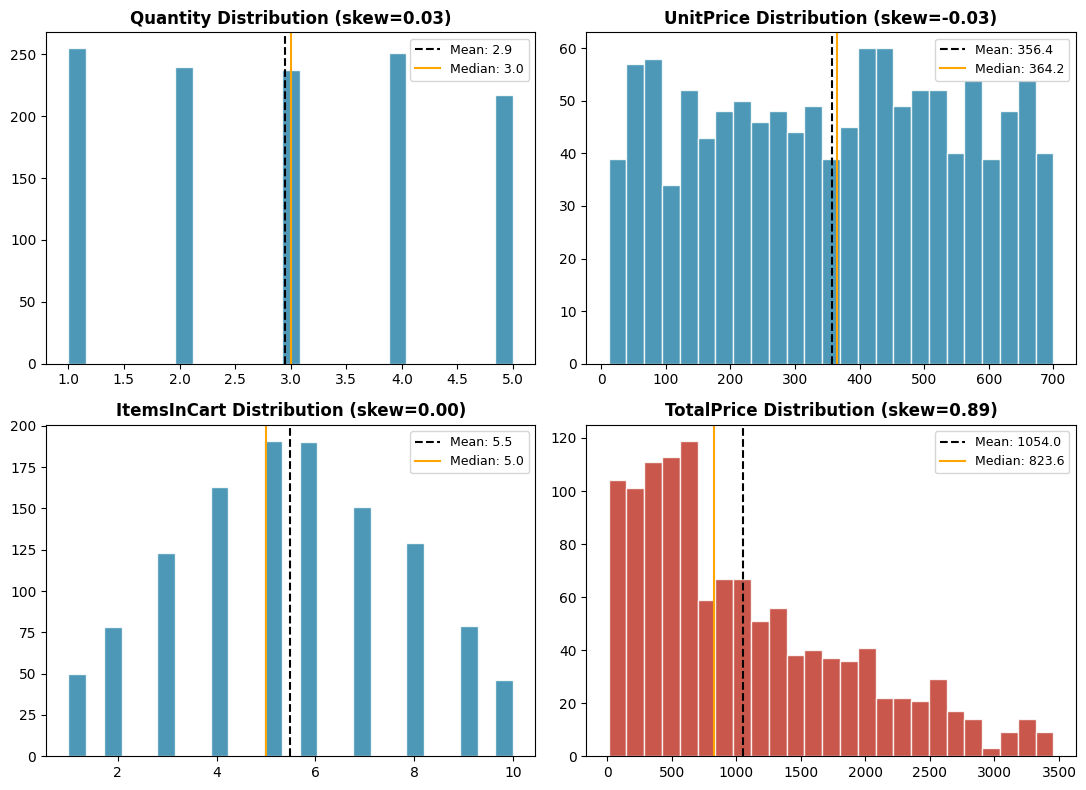

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
colors = ['#2E86AB', '#2E86AB', '#2E86AB', '#C0392B']
for ax, col, c in zip(axes.flat, numeric_cols, colors):
    ax.hist(df[col], bins=25, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'{col} Distribution (skew={df[col].skew():.2f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/01_distributions.png', dpi=150)
plt.show()

In [7]:
# --- Locating the Center of Gravity: Mean vs. Median ---
# TotalPrice is the column most likely to be pulled by high-value orders (the "Elon Musk effect").
mean_total = df['TotalPrice'].mean()
median_total = df['TotalPrice'].median()
pct_gap = (mean_total - median_total) / median_total * 100

print(f"TotalPrice -- Mean:   \${mean_total:,.2f}")
print(f"TotalPrice -- Median: \${median_total:,.2f}")
print(f"Gap: the mean sits {pct_gap:.1f}% above the median")
print(f"Skewness: {df['TotalPrice'].skew():.2f} (right-skewed -> a small number of high-value orders pull the average up)")

log_finding(
    f"TotalPrice is right-skewed (skew={df['TotalPrice'].skew():.2f}); the mean (${mean_total:,.0f}) "
    f"overstates the typical order by {pct_gap:.1f}% versus the median (${median_total:,.0f}). "
    f"The median is the more honest 'typical order value' for this dataset."
)

TotalPrice -- Mean:   \$1,053.97
TotalPrice -- Median: \$823.62
Gap: the mean sits 28.0% above the median
Skewness: 0.89 (right-skewed -> a small number of high-value orders pull the average up)
FINDING: TotalPrice is right-skewed (skew=0.89); the mean ($1,054) overstates the typical order by 28.0% versus the median ($824). The median is the more honest 'typical order value' for this dataset.


<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_575/2338469532.py:7: SyntaxWarning: invalid escape sequence '\$'
  print(f"TotalPrice -- Mean:   \${mean_total:,.2f}")
/tmp/ipykernel_575/2338469532.py:8: SyntaxWarning: invalid escape sequence '\$'
  print(f"TotalPrice -- Median: \${median_total:,.2f}")


## Phase 2 -- The Logic Skeleton: Five-Number Summary

Minimum, Q1, Median, Q3, Maximum for every numeric variable -- the structural skeleton behind every boxplot.


In [8]:
five_number = df[numeric_cols].describe(percentiles=[.25, .5, .75]).T[['min', '25%', '50%', '75%', 'max']]
five_number.columns = ['Minimum', 'Q1 (25th pct)', 'Median (50th pct)', 'Q3 (75th pct)', 'Maximum']
five_number.round(2)

,Minimum,Q1 (25th pct),Median (50th pct),Q3 (75th pct),Maximum
Quantity,1.00,2.00,3.00,4.00,5.00
UnitPrice,11.39,186.06,364.21,521.57,699.93
ItemsInCart,1.00,4.00,5.00,7.00,10.00
TotalPrice,11.39,410.52,823.62,1578.48,3456.40


In [9]:
# Basic descriptive statistics required by the brief: mean, median, count (+ std, for completeness)
basic_stats = df[numeric_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
basic_stats.round(2)

,count,mean,median,std,min,max
Quantity,1200.0,2.95,3.00,1.41,1.00,5.00
UnitPrice,1200.0,356.41,364.21,197.18,11.39,699.93
ItemsInCart,1200.0,5.48,5.00,2.28,1.00,10.00
TotalPrice,1200.0,1053.97,823.62,819.86,11.39,3456.40


## Phase 3 -- Unmasking the Outliers: Noise vs. Signal
*"Noise = data entry mistakes, typos -> clean/remove. Signal = fraud, VIP customers, rare events -> investigate."*

We apply both standard detection methods, per the brief:
- **IQR Method** -- robust against extreme values, best for 'dirty' business data: outlier if value `< Q1 - 1.5*IQR` or `> Q3 + 1.5*IQR`
- **Z-Score Method** -- sensitive to extreme values, best for normal distributions: flag if `|Z| > 3`


In [10]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)], lower, upper

def zscore_outliers(series):
    z = (series - series.mean()) / series.std()
    return series[z.abs() > 3]

outlier_report = []
for col in numeric_cols:
    iqr_out, lower, upper = iqr_outliers(df[col])
    z_out = zscore_outliers(df[col])
    outlier_report.append({
        'Column': col,
        'IQR outliers': len(iqr_out),
        'IQR bounds': f'[{lower:.1f}, {upper:.1f}]',
        'Z-score outliers (|z|>3)': len(z_out)
    })

outlier_df = pd.DataFrame(outlier_report)
outlier_df

,Column,IQR outliers,IQR bounds,Z-score outliers (|z|>3)
0,Quantity,0,"[-1.0, 7.0]",0
1,UnitPrice,0,"[-317.2, 1024.8]",0
2,ItemsInCart,0,"[-0.5, 11.5]",0
3,TotalPrice,8,"[-1341.4, 3330.4]",0


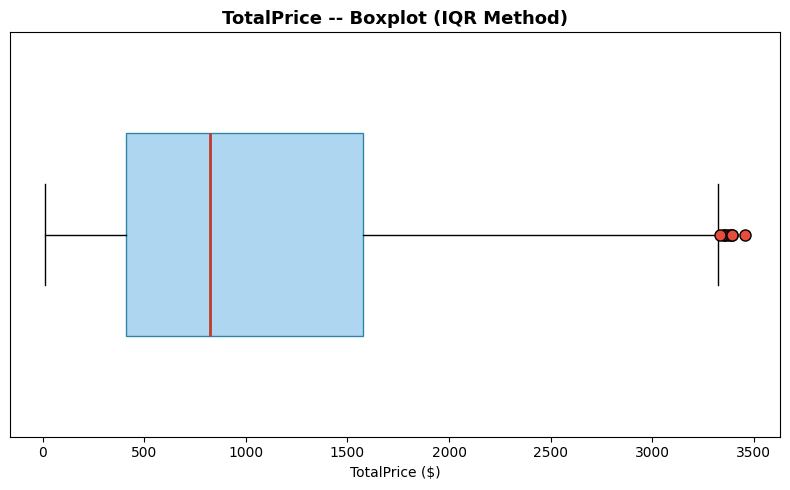

In [11]:
# Boxplot visualization for TotalPrice (the column with detected outliers)
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df['TotalPrice'], vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor='#AED6F1', color='#2E86AB'),
           medianprops=dict(color='#C0392B', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=8, markeredgecolor='black'))
ax.set_title('TotalPrice -- Boxplot (IQR Method)', fontsize=13, fontweight='bold')
ax.set_xlabel('TotalPrice ($)')
ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/02_boxplot_totalprice.png', dpi=150)
plt.show()

In [12]:
# Investigate the flagged TotalPrice outliers -- are they noise (errors) or signal (real large orders)?
flagged, lower, upper = iqr_outliers(df['TotalPrice'])
flagged_records = df.loc[flagged.index, ['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice', 'OrderStatus']]
flagged_records = flagged_records.sort_values('TotalPrice', ascending=False)
flagged_records

,OrderID,Product,Quantity,UnitPrice,TotalPrice,OrderStatus
789,ORD200789,Tablet,5,691.28,3456.40,Delivered
1122,ORD201122,Monitor,5,678.19,3390.95,Returned
632,ORD200632,Laptop,5,678.16,3390.80,Delivered
469,ORD200469,Chair,5,676.98,3384.90,Cancelled
328,ORD200328,Tablet,5,674.04,3370.20,Cancelled
107,ORD200107,Printer,5,670.75,3353.75,Shipped
326,ORD200326,Laptop,5,670.48,3352.40,Returned
1065,ORD201065,Printer,5,666.80,3334.00,Delivered


In [13]:
# Forensic check: do these outliers reconcile with Quantity x UnitPrice, and do they sit at sane values?
recon_check = (flagged_records['Quantity'] * flagged_records['UnitPrice']).round(2)
mismatches = (recon_check - flagged_records['TotalPrice']).abs() > 0.01
all_max_quantity = (flagged_records['Quantity'] == df['Quantity'].max()).all()

print(f"All flagged outliers reconcile with Quantity x UnitPrice: {(~mismatches).all()}")
print(f"All flagged outliers are at maximum Quantity ({df['Quantity'].max()}): {all_max_quantity}")
print(f"All flagged UnitPrice values are within the normal range "
      f"(min={df['UnitPrice'].min():.2f}, max={df['UnitPrice'].max():.2f}): "
      f"{flagged_records['UnitPrice'].between(df['UnitPrice'].min(), df['UnitPrice'].max()).all()}")

verdict = "SIGNAL (legitimate large orders)" if all_max_quantity and (~mismatches).all() else "NOISE (needs investigation)"
print(f"\nVerdict: {verdict}")

log_finding(
    f"{len(flagged_records)} orders flagged as TotalPrice outliers by the IQR method (all above ${upper:,.0f}). "
    f"All reconcile exactly with Quantity x UnitPrice and occur at the dataset's max Quantity (5) with "
    f"in-range UnitPrice -- this is SIGNAL (genuine high-value bulk orders), not data entry NOISE. "
    f"No Z-score outliers were found (|z|>3), confirming these are not extreme enough to distort the overall mean materially."
)

All flagged outliers reconcile with Quantity x UnitPrice: True
All flagged outliers are at maximum Quantity (5): True
All flagged UnitPrice values are within the normal range (min=11.39, max=699.93): True

Verdict: SIGNAL (legitimate large orders)
FINDING: 8 orders flagged as TotalPrice outliers by the IQR method (all above $3,330). All reconcile exactly with Quantity x UnitPrice and occur at the dataset's max Quantity (5) with in-range UnitPrice -- this is SIGNAL (genuine high-value bulk orders), not data entry NOISE. No Z-score outliers were found (|z|>3), confirming these are not extreme enough to distort the overall mean materially.


## Phase 4 -- Mapping Relationships: Correlation Analysis

**Metric:** Pearson correlation coefficient (r) -- measures the strength and direction of linear relationships. Dark red = +1.0 (perfect positive), white = 0.0 (no correlation), dark blue = -1.0 (perfect negative).


In [14]:
corr_matrix = df[numeric_cols].corr().round(3)
corr_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000,0.015,0.650,0.615
UnitPrice,0.015,1.000,0.001,0.717
ItemsInCart,0.650,0.001,1.000,0.393
TotalPrice,0.615,0.717,0.393,1.000


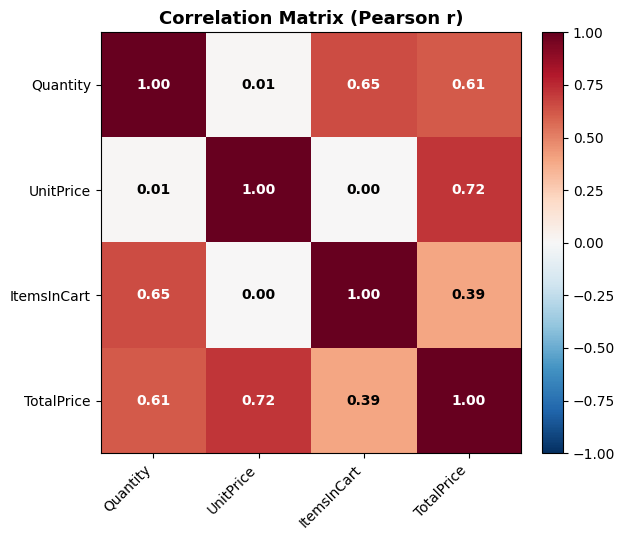

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.iloc[i,j]) > 0.5 else 'black', fontweight='bold')
ax.set_title('Correlation Matrix (Pearson r)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/03_correlation_heatmap.png', dpi=150)
plt.show()

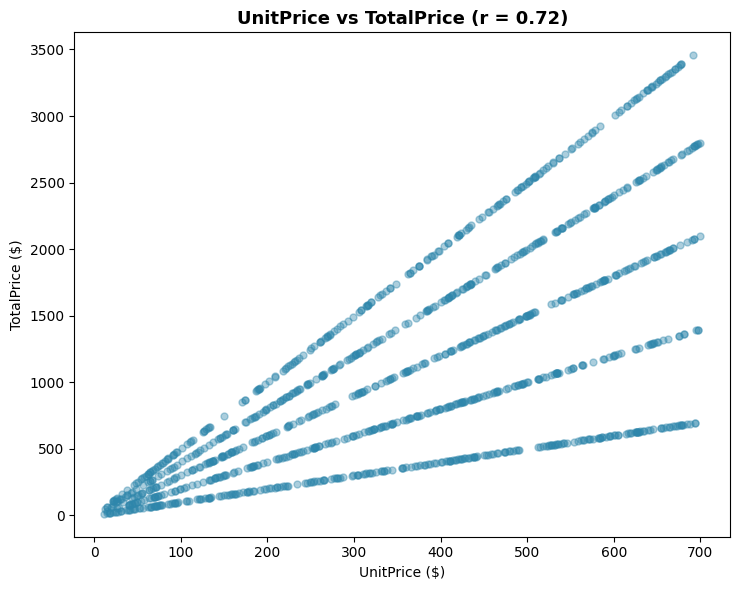

FINDING: UnitPrice shows the strongest linear relationship with TotalPrice (r=0.72), followed by Quantity (r=0.62). ItemsInCart correlates moderately with TotalPrice (r=0.39) but only weakly with UnitPrice (r=0.00), suggesting cart size and item price are largely independent customer behaviors.


In [16]:
# Strongest relationship: UnitPrice <-> TotalPrice
r = df['UnitPrice'].corr(df['TotalPrice'])
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.4, color='#2E86AB', s=25)
ax.set_xlabel('UnitPrice ($)'); ax.set_ylabel('TotalPrice ($)')
ax.set_title(f'UnitPrice vs TotalPrice (r = {r:.2f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/04_scatter_unitprice_totalprice.png', dpi=150)
plt.show()

log_finding(
    f"UnitPrice shows the strongest linear relationship with TotalPrice (r={r:.2f}), "
    f"followed by Quantity (r={df['Quantity'].corr(df['TotalPrice']):.2f}). "
    f"ItemsInCart correlates moderately with TotalPrice (r={df['ItemsInCart'].corr(df['TotalPrice']):.2f}) "
    f"but only weakly with UnitPrice (r={df['ItemsInCart'].corr(df['UnitPrice']):.2f}), suggesting cart size "
    f"and item price are largely independent customer behaviors."
)

In [17]:
# The Golden Rule: Correlation != Causation
print("FORENSIC NOTE:")
print("A correlation is a CLUE, not a VERDICT. Always check for hidden/confounding variables.")
print()
print("Example from this dataset: Quantity and ItemsInCart are correlated "
      f"(r={df['Quantity'].corr(df['ItemsInCart']):.2f}), but neither *causes* the other -- both are "
      "more plausibly driven by a hidden variable such as customer purchasing behavior or order size "
      "preference. We report the association; we do not claim one variable drives the other.")

FORENSIC NOTE:
A correlation is a CLUE, not a VERDICT. Always check for hidden/confounding variables.

Example from this dataset: Quantity and ItemsInCart are correlated (r=0.65), but neither *causes* the other -- both are more plausibly driven by a hidden variable such as customer purchasing behavior or order size preference. We report the association; we do not claim one variable drives the other.


## Phase 5 -- Trends Over Time & Categorical Breakdowns

Moving from univariate/bivariate statistics to the bigger picture: how does revenue move over time, and how is it distributed across products, payment methods, and acquisition channels?


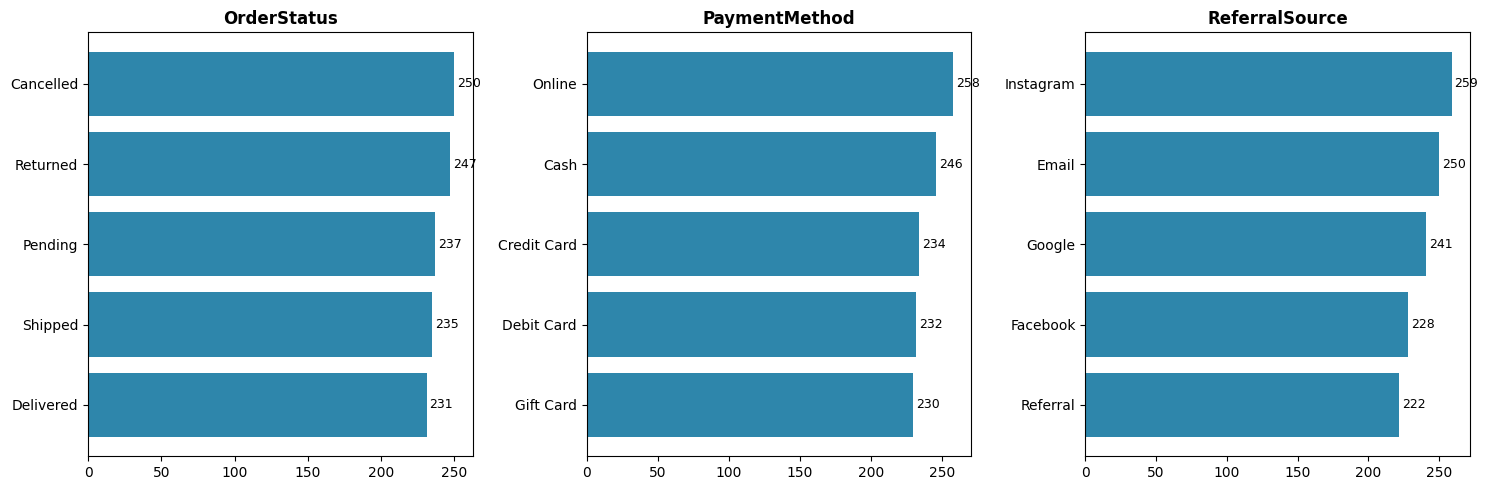

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['OrderStatus', 'PaymentMethod', 'ReferralSource']):
    counts = df[col].value_counts().sort_values(ascending=True)
    ax.barh(counts.index, counts.values, color='#2E86AB')
    ax.set_title(col, fontsize=12, fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/05_categorical_breakdowns.png', dpi=150)
plt.show()

In [19]:
product_summary = df.groupby('Product')['TotalPrice'].agg(['count', 'mean', 'median', 'sum']).round(2)
product_summary = product_summary.sort_values('sum', ascending=False)
product_summary.columns = ['Order Count', 'Mean Order Value', 'Median Order Value', 'Total Revenue']
product_summary

,Order Count,Mean Order Value,Median Order Value,Total Revenue
Product,,,,
Chair,178,1098.99,928.58,195620.11
Printer,181,1080.73,857.40,195612.61
Laptop,173,1110.56,915.64,192126.56
Tablet,179,1042.28,786.66,186568.95
Monitor,163,1077.62,853.40,175651.41
Desk,170,985.06,784.39,167459.93
Phone,156,972.58,691.71,151722.39


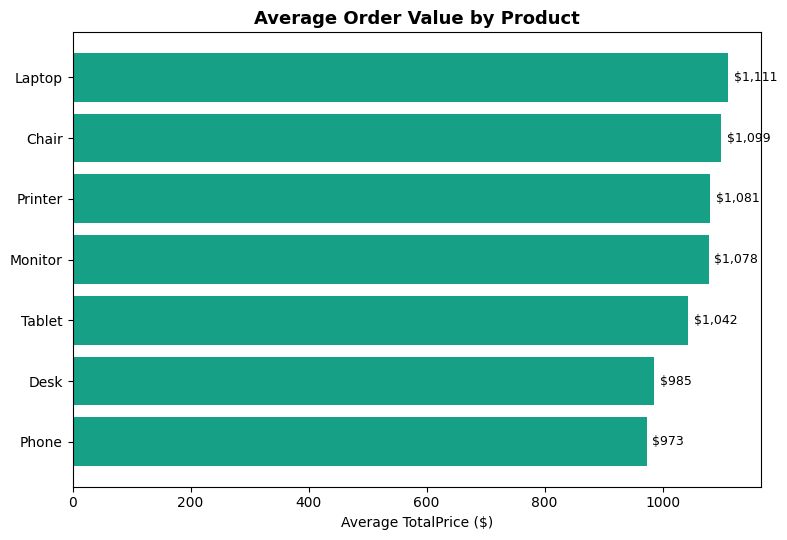

FINDING: 'Chair' generates the highest total revenue ($195,620) across 178 orders, though average order values across all 7 products are fairly close ($973-$1,111), indicating revenue differences are driven more by order volume than by per-order price differences between products.


In [20]:
fig, ax = plt.subplots(figsize=(8, 5.5))
avg_by_product = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=True)
ax.barh(avg_by_product.index, avg_by_product.values, color='#16A085')
ax.set_xlabel('Average TotalPrice ($)')
ax.set_title('Average Order Value by Product', fontsize=13, fontweight='bold')
for i, v in enumerate(avg_by_product.values):
    ax.text(v + 10, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/06_avg_value_by_product.png', dpi=150)
plt.show()

top_product = product_summary['Total Revenue'].idxmax()
log_finding(
    f"'{top_product}' generates the highest total revenue (${product_summary.loc[top_product, 'Total Revenue']:,.0f}) "
    f"across {int(product_summary.loc[top_product, 'Order Count'])} orders, though average order values across "
    f"all 7 products are fairly close (${product_summary['Mean Order Value'].min():,.0f}-"
    f"${product_summary['Mean Order Value'].max():,.0f}), indicating revenue differences are driven more by "
    f"order volume than by per-order price differences between products."
)

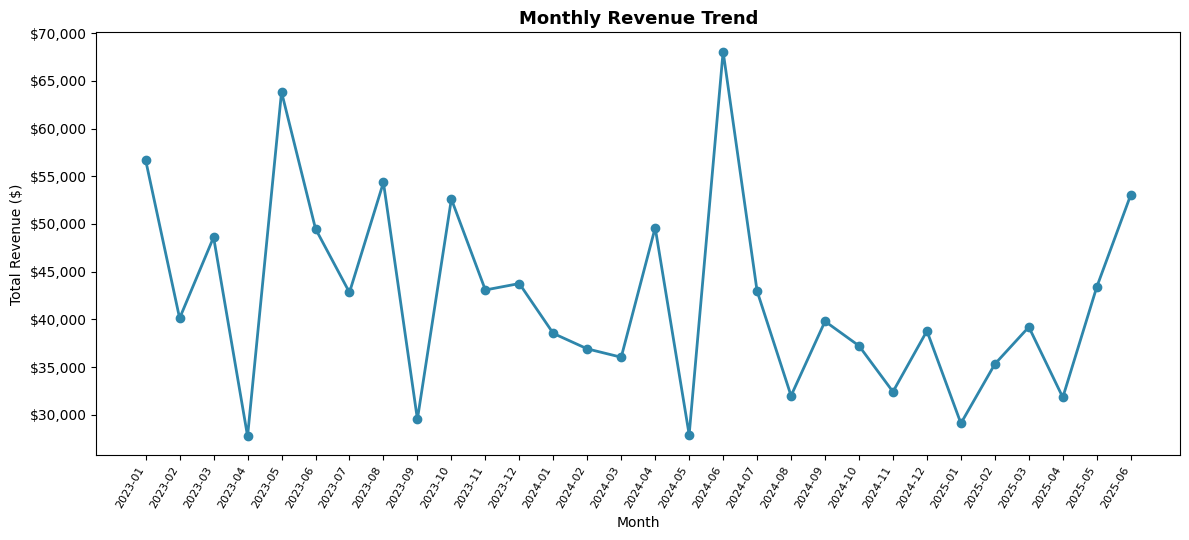

In [21]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly = df.groupby('Month')['TotalPrice'].agg(['count', 'sum']).reset_index()
monthly.columns = ['Month', 'Order Count', 'Total Revenue']

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(monthly['Month'], monthly['Total Revenue'], marker='o', color='#2E86AB', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Revenue ($)'); ax.set_xlabel('Month')
plt.xticks(rotation=60, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/07_monthly_trend.png', dpi=150)
plt.show()

In [22]:
best_month = monthly.loc[monthly['Total Revenue'].idxmax()]
worst_month = monthly.loc[monthly['Total Revenue'].idxmin()]
order_status_cancelled_returned = df['OrderStatus'].isin(['Cancelled', 'Returned']).sum()
pct_cancelled_returned = order_status_cancelled_returned / len(df) * 100

print(f"Strongest month: {best_month['Month']} (${best_month['Total Revenue']:,.0f} across {int(best_month['Order Count'])} orders)")
print(f"Weakest month:   {worst_month['Month']} (${worst_month['Total Revenue']:,.0f} across {int(worst_month['Order Count'])} orders)")
print(f"Cancelled + Returned orders: {order_status_cancelled_returned} of {len(df)} ({pct_cancelled_returned:.1f}%)")

log_finding(
    f"Revenue is fairly volatile month to month, ranging from ${worst_month['Total Revenue']:,.0f} "
    f"({worst_month['Month']}) to ${best_month['Total Revenue']:,.0f} ({best_month['Month']}), with no single "
    f"dominant seasonal pattern visible across the {monthly.shape[0]}-month window covered by the data."
)

log_finding(
    f"{pct_cancelled_returned:.1f}% of all orders end in 'Cancelled' or 'Returned' status "
    f"({order_status_cancelled_returned} of {len(df)} orders) -- nearly even with the {df['OrderStatus'].value_counts().get('Delivered',0)} "
    f"'Delivered' orders, which is a material fulfillment/quality signal worth flagging to operations."
)

Strongest month: 2024-06 ($68,069 across 53 orders)
Weakest month:   2023-04 ($27,752 across 31 orders)
Cancelled + Returned orders: 497 of 1200 (41.4%)
FINDING: Revenue is fairly volatile month to month, ranging from $27,752 (2023-04) to $68,069 (2024-06), with no single dominant seasonal pattern visible across the 30-month window covered by the data.
FINDING: 41.4% of all orders end in 'Cancelled' or 'Returned' status (497 of 1200 orders) -- nearly even with the 231 'Delivered' orders, which is a material fulfillment/quality signal worth flagging to operations.


## The "So What?" Test -- Translating Data into Business Diagnosis

Per the brief: *"Don't title a slide 'Data'. Title it 'Revenue Grew 19%.'"* Below, every statistical finding from this notebook is translated from "what the data says" into "the business diagnosis."


In [23]:
so_what_table = pd.DataFrame([
    {
        'What the data says': f"TotalPrice is right-skewed (skew={df['TotalPrice'].skew():.2f}); mean (${mean_total:,.0f}) > median (${median_total:,.0f})",
        'The business diagnosis': "A handful of large bulk orders inflate the 'average sale' figure -- use the median when setting realistic sales targets or typical-customer benchmarks"
    },
    {
        'What the data says': f"{len(flagged_records)} orders flagged as statistical outliers in TotalPrice (IQR method)",
        'The business diagnosis': "These are legitimate maximum-quantity bulk orders, not data errors -- they represent a high-value customer segment worth a dedicated retention or bulk-discount strategy"
    },
    {
        'What the data says': f"UnitPrice correlates strongly with TotalPrice (r={df['UnitPrice'].corr(df['TotalPrice']):.2f})",
        'The business diagnosis': "Premium-priced products are the primary lever for revenue growth -- pricing strategy matters more than encouraging larger cart sizes"
    },
    {
        'What the data says': f"{pct_cancelled_returned:.1f}% of orders are Cancelled or Returned",
        'The business diagnosis': "Nearly 1 in 2 orders fails to complete successfully -- this is a fulfillment/quality issue that may be costing more revenue than any marketing initiative could recover"
    },
    {
        'What the data says': f"'{top_product}' leads total revenue at ${product_summary.loc[top_product, 'Total Revenue']:,.0f}",
        'The business diagnosis': f"'{top_product}' is the strongest current revenue driver and a candidate for continued inventory investment and marketing focus"
    },
])
so_what_table

,What the data says,The business diagnosis
0,TotalPrice is right-skewed (skew=0.89); mean (...,A handful of large bulk orders inflate the 'av...
1,8 orders flagged as statistical outliers in To...,These are legitimate maximum-quantity bulk ord...
2,UnitPrice correlates strongly with TotalPrice ...,Premium-priced products are the primary lever ...
3,41.4% of orders are Cancelled or Returned,Nearly 1 in 2 orders fails to complete success...
4,"'Chair' leads total revenue at $195,620",'Chair' is the strongest current revenue drive...


## Export -- Processed Artifacts

We persist the numeric outputs of this investigation so they can be reused by later projects (dashboards, modeling) without re-running the analysis.


In [24]:
# Export summary statistics
basic_stats.to_csv(f'{PROCESSED_DIR}/eda_summary_statistics.csv')

# Export correlation matrix
corr_matrix.to_csv(f'{PROCESSED_DIR}/correlation_matrix.csv')

# Export flagged outliers
flagged_records.to_csv(f'{PROCESSED_DIR}/flagged_outliers.csv', index=False)

print("Exported:")
print(f" - {PROCESSED_DIR}/eda_summary_statistics.csv")
print(f" - {PROCESSED_DIR}/correlation_matrix.csv")
print(f" - {PROCESSED_DIR}/flagged_outliers.csv")


Exported:
 - ../data/processed/eda_summary_statistics.csv
 - ../data/processed/correlation_matrix.csv
 - ../data/processed/flagged_outliers.csv


In [25]:
# Export the running list of key findings as JSON, for the Executive Summary document
with open(f'{DOCS_DIR}/key_findings.json', 'w') as f:
    json.dump(findings, f, indent=2)

print(f"Exported {len(findings)} findings to {DOCS_DIR}/key_findings.json")
for i, f_ in enumerate(findings, 1):
    print(f"\n{i}. {f_}")


Exported 6 findings to ../docs/key_findings.json

1. TotalPrice is right-skewed (skew=0.89); the mean ($1,054) overstates the typical order by 28.0% versus the median ($824). The median is the more honest 'typical order value' for this dataset.

2. 8 orders flagged as TotalPrice outliers by the IQR method (all above $3,330). All reconcile exactly with Quantity x UnitPrice and occur at the dataset's max Quantity (5) with in-range UnitPrice -- this is SIGNAL (genuine high-value bulk orders), not data entry NOISE. No Z-score outliers were found (|z|>3), confirming these are not extreme enough to distort the overall mean materially.

3. UnitPrice shows the strongest linear relationship with TotalPrice (r=0.72), followed by Quantity (r=0.62). ItemsInCart correlates moderately with TotalPrice (r=0.39) but only weakly with UnitPrice (r=0.00), suggesting cart size and item price are largely independent customer behaviors.

4. 'Chair' generates the highest total revenue ($195,620) across 178 or

---

## Conclusion -- The Verdict

EDA is the diagnostic phase for data integrity and insight. By the end of this notebook:

- [x] **Distributions** characterized -- symmetrical (Quantity, UnitPrice, ItemsInCart) vs. skewed (TotalPrice)
- [x] **Five-number summaries** computed for every numeric variable
- [x] **Outliers** detected (IQR + Z-score) and correctly classified as **signal**, not noise
- [x] **Correlations** mapped, with the Correlation != Causation warning explicitly applied
- [x] **Trends** identified across time, product, and order status
- [x] Every finding translated through the **"So What?" Test** into an actionable business diagnosis

> *"You are the translator between data and decision."*

**Outputs produced:**
| File | Description |
|---|---|
| `data/processed/eda_summary_statistics.csv` | Mean/median/std/min/max for all numeric columns |
| `data/processed/correlation_matrix.csv` | Pearson correlation matrix |
| `data/processed/flagged_outliers.csv` | Outlier records flagged by the IQR method |
| `docs/key_findings.json` | Machine-readable list of key findings |
| `docs/EXECUTIVE_SUMMARY.md` | Stakeholder-facing 4-part executive summary |
| `visuals/*.png` | All charts generated in this notebook |

*DecodeLabs | Industrial Training Kit | Batch 2026*
